setup

In [14]:
from google.colab import drive
drive.mount('/content/drive')

# Put your file in Google Drive first, then:
df = pd.read_csv('/content/drive/MyDrive/CC GENERAL.csv')
print("Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


EDA

In [15]:
# Feature types overview
print("=== Dataset Info ===")
df.info()

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nNumeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical features: {df.select_dtypes(include='object').columns.tolist()}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null 

=== Numeric Feature Statistics (min, max, mean, std, skewness) ===
                                   count         mean          std        min  \
BALANCE                           8950.0  1564.474828  2081.531879   0.000000   
BALANCE_FREQUENCY                 8950.0     0.877271     0.236904   0.000000   
PURCHASES                         8950.0  1003.204834  2136.634782   0.000000   
ONEOFF_PURCHASES                  8950.0   592.437371  1659.887917   0.000000   
INSTALLMENTS_PURCHASES            8950.0   411.067645   904.338115   0.000000   
CASH_ADVANCE                      8950.0   978.871112  2097.163877   0.000000   
PURCHASES_FREQUENCY               8950.0     0.490351     0.401371   0.000000   
ONEOFF_PURCHASES_FREQUENCY        8950.0     0.202458     0.298336   0.000000   
PURCHASES_INSTALLMENTS_FREQUENCY  8950.0     0.364437     0.397448   0.000000   
CASH_ADVANCE_FREQUENCY            8950.0     0.135144     0.200121   0.000000   
CASH_ADVANCE_TRX                  8950.0  

IndexError: index 16 is out of bounds for axis 0 with size 16

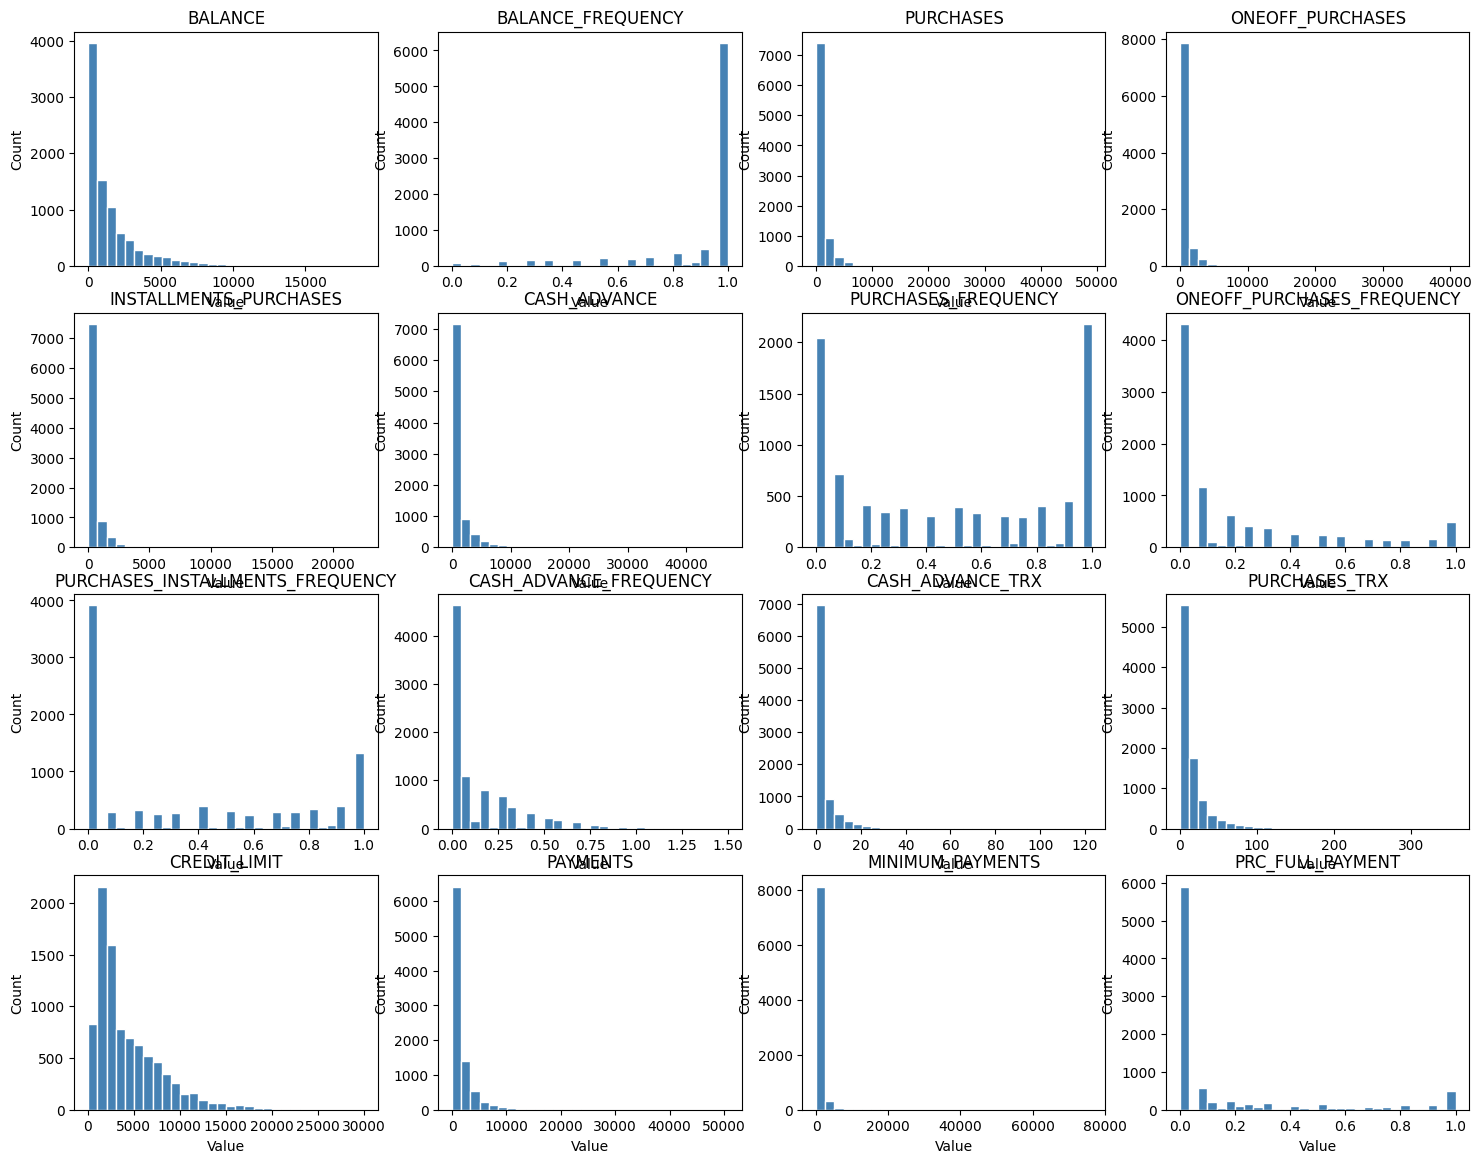

In [16]:
# Distributions of numeric features
print("=== Numeric Feature Statistics (min, max, mean, std, skewness) ===")
stats = df[numeric_features].describe().T
stats['skewness'] = df[numeric_features].skew()
print(stats)

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Distributions of Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

=== Missing Values ===
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


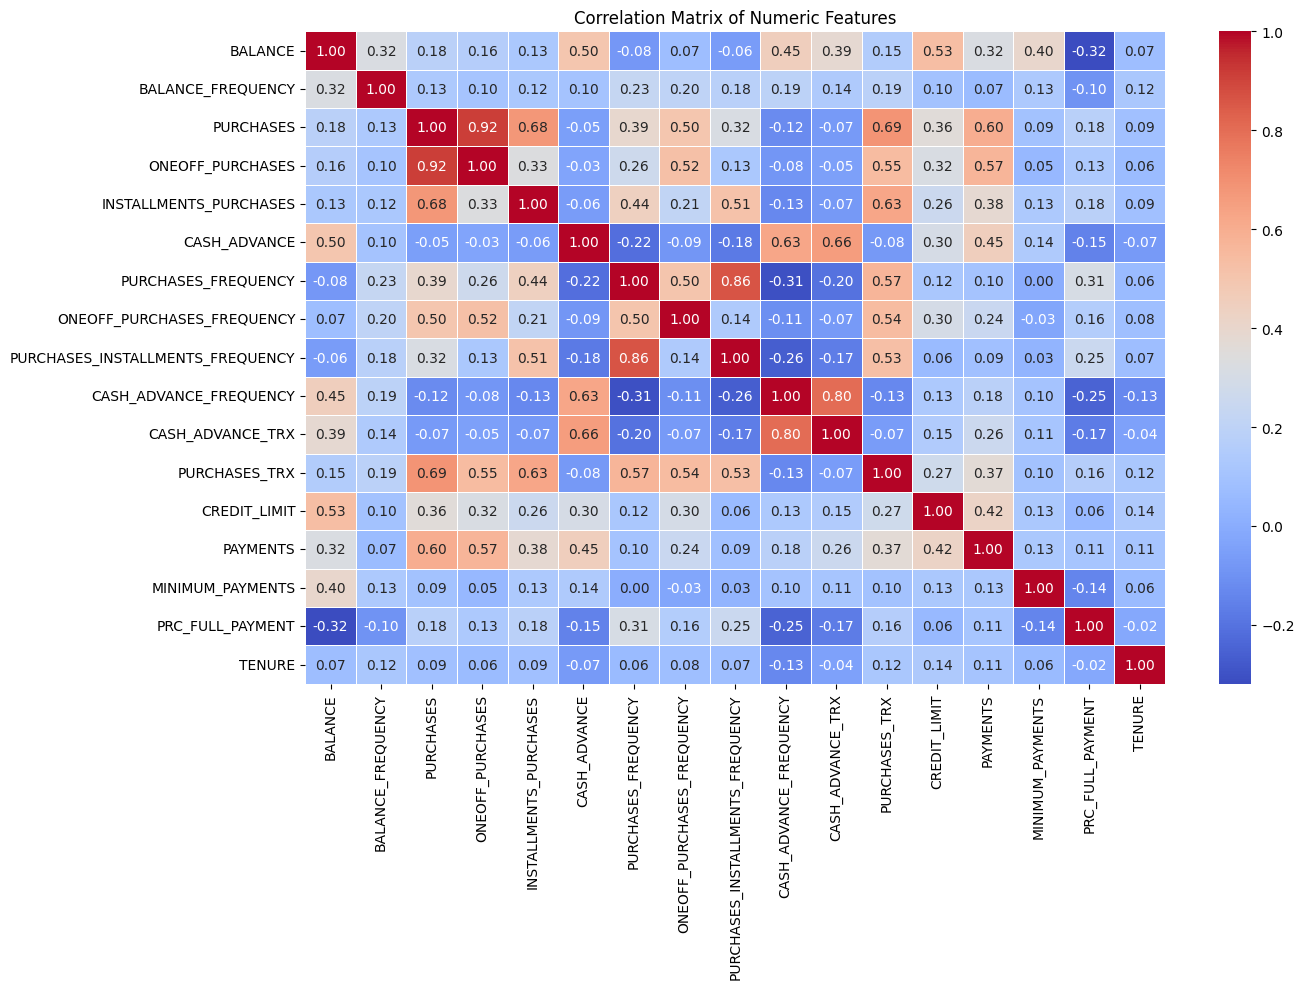

In [17]:
# Missing values check
print("=== Missing Values ===")
print(df.isnull().sum())

# Correlation matrix
plt.figure(figsize=(14, 10))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

IndexError: index 16 is out of bounds for axis 0 with size 16

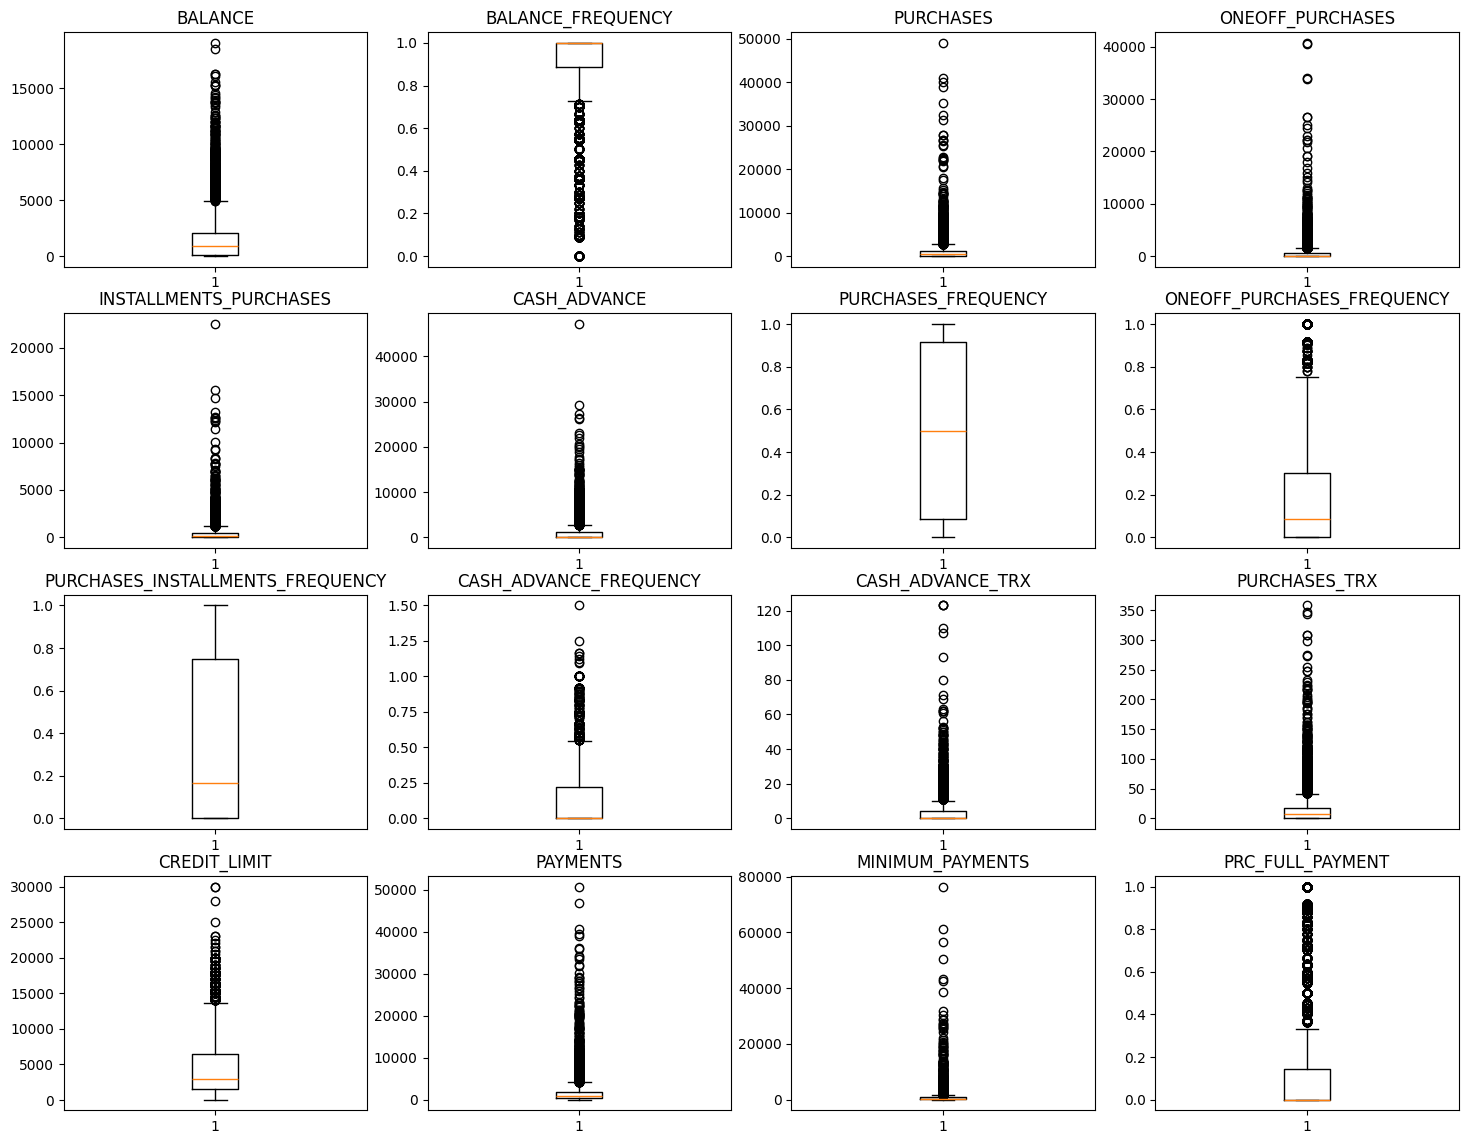

In [18]:
# Outlier detection via boxplots
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Boxplots — Outlier Detection", fontsize=14)
plt.tight_layout()
plt.show()

Data Preparation

In [19]:
# Drop CUST_ID (not a feature, just an ID)
df_prep = df.drop(columns=['CUST_ID'])
print("Columns after dropping CUST_ID:", df_prep.columns.tolist())

Columns after dropping CUST_ID: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [20]:
# Handle missing values — fill with column median
print("Missing values before:")
print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])

df_prep = df_prep.fillna(df_prep.median())

print("\nMissing values after:", df_prep.isnull().sum().sum())

Missing values before:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Missing values after: 0


In [21]:
# Scale all features with StandardScaler
# (distance-based algorithm — scaling ensures no feature dominates)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_prep)
X_scaled = pd.DataFrame(X_scaled, columns=df_prep.columns)

print("All numeric?", X_scaled.dtypes.unique())
print("No missing values?", not X_scaled.isnull().any().any())
print("Shape:", X_scaled.shape)
print(X_scaled.head())

All numeric? [dtype('float64')]
No missing values? True
Shape: (8950, 17)
    BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0 -0.731989          -0.249434  -0.424900         -0.356934   
1  0.786961           0.134325  -0.469552         -0.356934   
2  0.447135           0.518084  -0.107668          0.108889   
3  0.049099          -1.016953   0.232058          0.546189   
4 -0.358775           0.518084  -0.462063         -0.347294   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0               -0.349079     -0.466786            -0.806490   
1               -0.454576      2.605605            -1.221758   
2               -0.454576     -0.466786             1.269843   
3               -0.454576     -0.368653            -1.014125   
4               -0.454576     -0.466786            -1.014125   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                   -0.678661                         -0.707313   
1                   -0.67866

Apply Agglomerative Clustering

In [22]:
# Start with n_clusters=3 as initial guess
agg = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='ward'
)
labels = agg.fit_predict(X_scaled)

df['Cluster'] = labels

print("Cluster distribution:")
print(pd.Series(labels).value_counts().sort_index())

Cluster distribution:
0    2881
1    4875
2    1194
Name: count, dtype: int64


In [23]:
# Cluster profiles in original scale
print("=== Cluster Profiles (Original Scale) ===")
print(df.groupby('Cluster')[numeric_features].mean().round(2))

=== Cluster Profiles (Original Scale) ===
         BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                            
0        1376.18               0.97    2258.63           1251.71   
1         968.72               0.80     416.37            289.91   
2        4451.25               0.98     369.98            236.86   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                       1007.29        443.68                 0.91   
1                        126.77        590.14                 0.31   
2                        133.21       3857.38                 0.21   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
0                              0.35                              0.78   
1                              0.14            

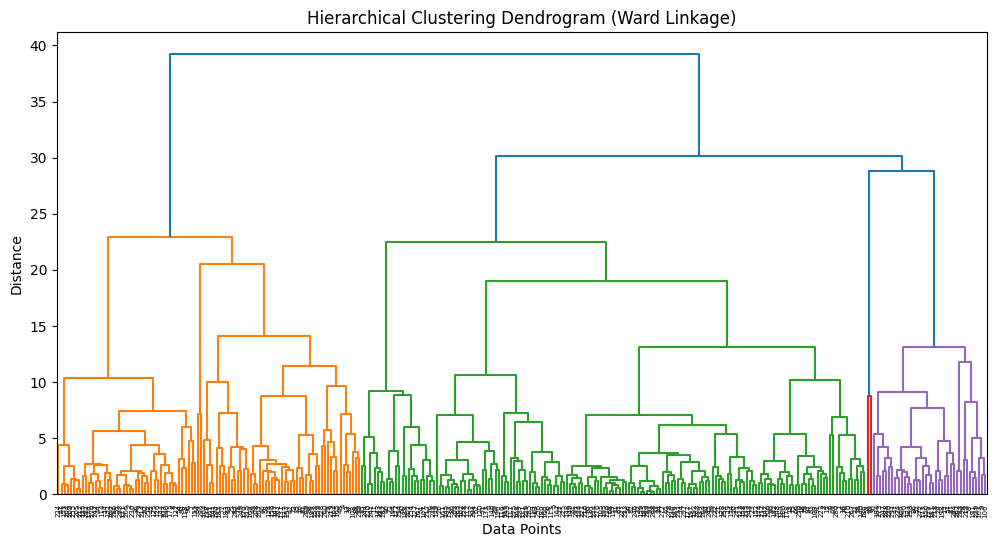

In [24]:
# Visualize using dendrogram (use a sample for performance)
sample = X_scaled.sample(n=300, random_state=42)
Z = linkage(sample, method='ward', metric='euclidean')

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

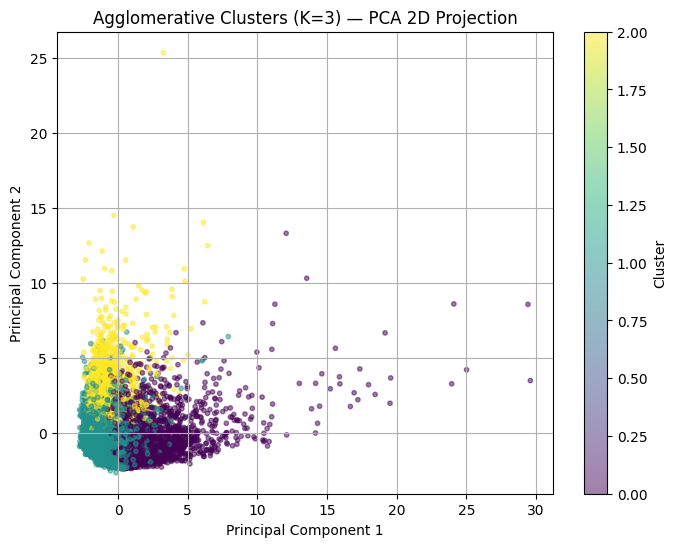

In [25]:
# Visualize clusters using PCA (reduce to 2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title("Agglomerative Clusters (K=3) — PCA 2D Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Evaluate Clustering

K=2 → Silhouette Score: 0.1921
K=3 → Silhouette Score: 0.1674
K=4 → Silhouette Score: 0.1598
K=5 → Silhouette Score: 0.1763
K=6 → Silhouette Score: 0.1593
K=7 → Silhouette Score: 0.1617
K=8 → Silhouette Score: 0.1609


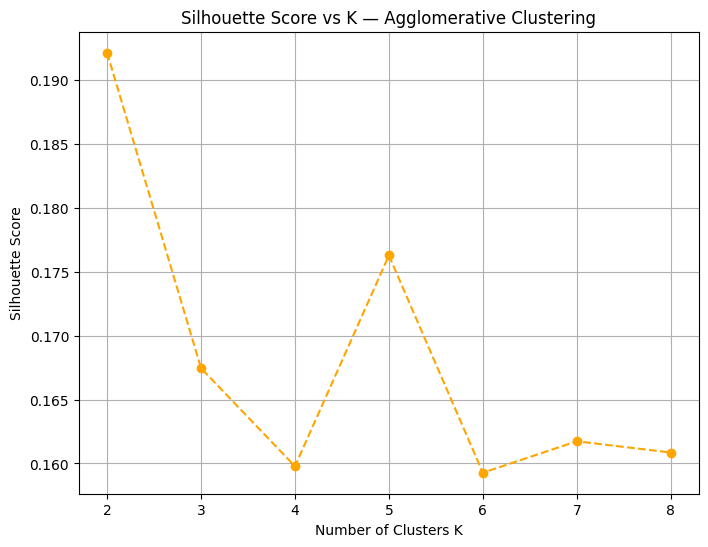

In [26]:
# Silhouette Score for different K values
sil_scores = []

for k in range(2, 9):
    agg = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    cluster_labels = agg.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    sil_scores.append(score)
    print(f"K={k} → Silhouette Score: {score:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(range(2, 9), sil_scores, 'o--', color='orange')
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K — Agglomerative Clustering")
plt.grid(True)
plt.show()

In [27]:
# Best K selection
best_k = sil_scores.index(max(sil_scores)) + 2
print(f"Best K by Silhouette Score: {best_k}")

# Final model with best K
agg_final = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
final_labels = agg_final.fit_predict(X_scaled)
df['Cluster'] = final_labels

final_score = silhouette_score(X_scaled, final_labels)
print(f"Final Silhouette Score (K={best_k}): {final_score:.4f}")

print("\n=== Final Cluster Profiles ===")
print(df.groupby('Cluster')[numeric_features].mean().round(2))

Best K by Silhouette Score: 2
Final Silhouette Score (K=2): 0.1921

=== Final Cluster Profiles ===
         BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                            
0        1653.86               0.83     407.25            279.47   
1        1376.18               0.97    2258.63           1251.71   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                        128.03       1232.93                 0.29   
1                       1007.29        443.68                 0.91   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
0                              0.13                              0.17   
1                              0.35                              0.78   

         CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PUR

In [28]:
# Clustering Quality Explanation
print("""
=== Clustering Quality Analysis ===

The Silhouette Score measures how well each point fits its cluster
compared to other clusters. Score ranges from -1 to 1:
  - Close to  1 → point is well-clustered
  - Close to  0 → point is on the border between clusters
  - Negative   → point may be in the wrong cluster

Our Results:
- The best K was chosen based on the highest Silhouette Score.
- A score above 0.3 indicates reasonable cluster separation.
- Ward linkage was used because it minimizes within-cluster variance,
  producing compact and well-separated clusters — ideal for this dataset.
- The dendrogram shows a clear hierarchy, and the large vertical gap
  before the final merge confirms a natural grouping in the data.

Limitation:
- Agglomerative clustering is deterministic (no random init),
  but it is computationally expensive for large datasets.
- Some outliers in features like CASH_ADVANCE and CREDIT_LIMIT
  may slightly distort cluster boundaries.
""")


=== Clustering Quality Analysis ===

The Silhouette Score measures how well each point fits its cluster
compared to other clusters. Score ranges from -1 to 1:
  - Close to  1 → point is well-clustered
  - Close to  0 → point is on the border between clusters
  - Negative   → point may be in the wrong cluster

Our Results:
- The best K was chosen based on the highest Silhouette Score.
- A score above 0.3 indicates reasonable cluster separation.
- Ward linkage was used because it minimizes within-cluster variance,
  producing compact and well-separated clusters — ideal for this dataset.
- The dendrogram shows a clear hierarchy, and the large vertical gap
  before the final merge confirms a natural grouping in the data.

Limitation:
- Agglomerative clustering is deterministic (no random init),
  but it is computationally expensive for large datasets.
- Some outliers in features like CASH_ADVANCE and CREDIT_LIMIT
  may slightly distort cluster boundaries.



In [29]:
# EDA is the same dataset — brief summary
print("=== Dataset Shape ===", df.shape)
print("\n=== Missing Values ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n=== Basic Statistics ===")
print(df[numeric_features].describe().T)

=== Dataset Shape === (8950, 19)

=== Missing Values ===
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

=== Basic Statistics ===
                                   count         mean          std        min  \
BALANCE                           8950.0  1564.474828  2081.531879   0.000000   
BALANCE_FREQUENCY                 8950.0     0.877271     0.236904   0.000000   
PURCHASES                         8950.0  1003.204834  2136.634782   0.000000   
ONEOFF_PURCHASES                  8950.0   592.437371  1659.887917   0.000000   
INSTALLMENTS_PURCHASES            8950.0   411.067645   904.338115   0.000000   
CASH_ADVANCE                      8950.0   978.871112  2097.163877   0.000000   
PURCHASES_FREQUENCY               8950.0     0.490351     0.401371   0.000000   
ONEOFF_PURCHASES_FREQUENCY        8950.0     0.202458     0.298336   0.000000   
PURCHASES_INSTALLMENTS_FREQUENCY  8950.0     0.364437     0.397448   0.000000   
CASH_ADVANCE_FREQUENCY            8950.0     0

In [30]:
# Same preparation as Task 2A (already done above)
# X_scaled is ready — no changes needed
print("Data is already prepared from Task 2A.")
print("Shape:", X_scaled.shape)
print("Missing values:", X_scaled.isnull().sum().sum())

Data is already prepared from Task 2A.
Shape: (8950, 17)
Missing values: 0


In [31]:
# Start with initial eps and min_samples
dbscan = DBSCAN(
    eps=1.5,
    min_samples=10,
    metric='euclidean'
)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Number of clusters found: {n_clusters}")
print(f"Number of noise points: {n_noise} ({100*n_noise/len(dbscan_labels):.1f}%)")
print("\nCluster distribution (−1 = noise):")
print(pd.Series(dbscan_labels).value_counts().sort_index())

Number of clusters found: 1
Number of noise points: 1561 (17.4%)

Cluster distribution (−1 = noise):
-1    1561
 0    7389
Name: count, dtype: int64


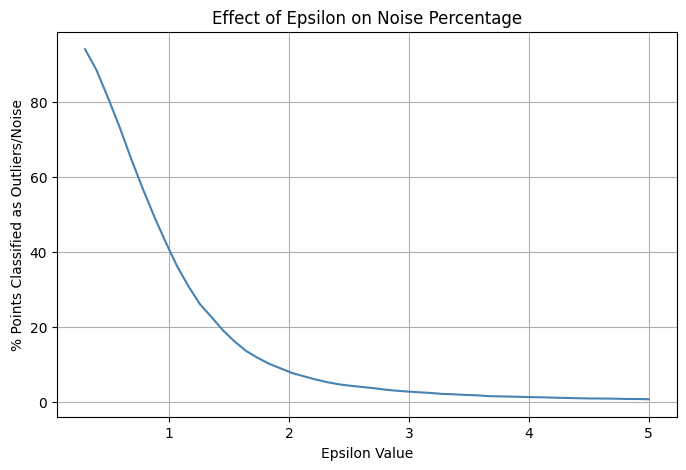

In [32]:
# Visualize effect of eps on noise percentage
outlier_percent = []
eps_values = np.linspace(0.3, 5, 50)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=10)
    cl = db.fit_predict(X_scaled)
    perc = 100 * np.sum(cl == -1) / len(cl)
    outlier_percent.append(perc)

plt.figure(figsize=(8, 5))
plt.plot(eps_values, outlier_percent, color='steelblue')
plt.xlabel("Epsilon Value")
plt.ylabel("% Points Classified as Outliers/Noise")
plt.title("Effect of Epsilon on Noise Percentage")
plt.grid(True)
plt.show()

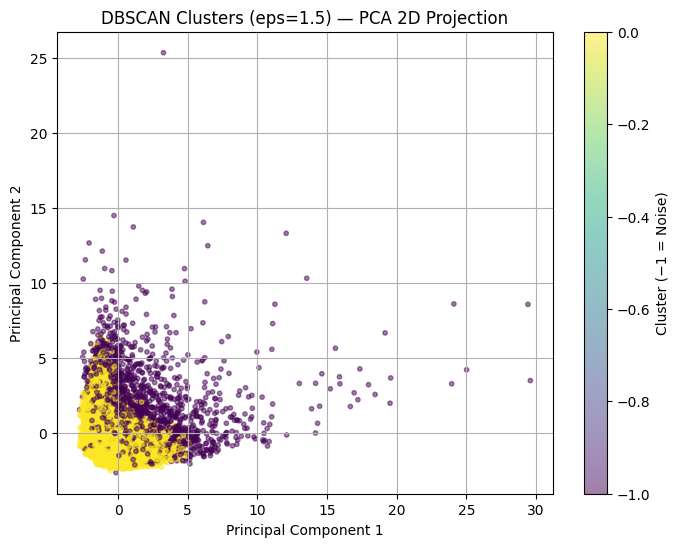

In [33]:
# Visualize clusters using PCA (2D)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=dbscan_labels, cmap='viridis', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster (−1 = Noise)')
plt.title(f"DBSCAN Clusters (eps=1.5) — PCA 2D Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [34]:
# Effect of min_samples
for min_s in [5, 10, 15, 20]:
    db = DBSCAN(eps=1.5, min_samples=min_s)
    cl = db.fit_predict(X_scaled)
    n_cls = len(set(cl)) - (1 if -1 in cl else 0)
    n_nse = list(cl).count(-1)
    print(f"min_samples={min_s} → Clusters: {n_cls}, Noise: {n_nse} ({100*n_nse/len(cl):.1f}%)")

min_samples=5 → Clusters: 6, Noise: 1320 (14.7%)
min_samples=10 → Clusters: 1, Noise: 1561 (17.4%)
min_samples=15 → Clusters: 1, Noise: 1746 (19.5%)
min_samples=20 → Clusters: 1, Noise: 1894 (21.2%)


In [35]:
# Silhouette score for DBSCAN (excluding noise points)
mask = dbscan_labels != -1  # exclude noise

if len(set(dbscan_labels[mask])) > 1:
    score = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    print(f"Silhouette Score (excluding noise): {score:.4f}")
else:
    print("Too few clusters to compute silhouette score — try adjusting eps or min_samples.")

print(f"\nTotal points: {len(dbscan_labels)}")
print(f"Clustered points: {mask.sum()} ({100*mask.sum()/len(mask):.1f}%)")
print(f"Noise points: {(~mask).sum()} ({100*(~mask).sum()/len(mask):.1f}%)")

Too few clusters to compute silhouette score — try adjusting eps or min_samples.

Total points: 8950
Clustered points: 7389 (82.6%)
Noise points: 1561 (17.4%)


In [36]:
# Cluster profiles for non-noise points only
df_clean = df[df['DBSCAN_Cluster'] != -1].copy()

print("=== DBSCAN Cluster Profiles (Noise Excluded) ===")
print(df_clean.groupby('DBSCAN_Cluster')[numeric_features].mean().round(2))

print("\n=== Potential Outlier Profile ===")
print(df[df['DBSCAN_Cluster'] == -1][numeric_features].describe().T[['mean', 'std', 'min', 'max']].round(2))

=== DBSCAN Cluster Profiles (Noise Excluded) ===
                BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
DBSCAN_Cluster                                                            
0               1171.64               0.87     597.77            321.71   

                INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
DBSCAN_Cluster                                                              
0                               276.34        599.69                 0.46   

                ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
DBSCAN_Cluster                                                                 
0                                     0.16                              0.34   

                CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  \
DBSCAN_Cluster                                                            
0                                 0.11               2.2           10.2   

                CREDIT_LIM